
--- Training SVM using SGD ---
Weight vector (w): [[ 1.89376482 -0.27539001]]
Bias (b): [0.23791293]


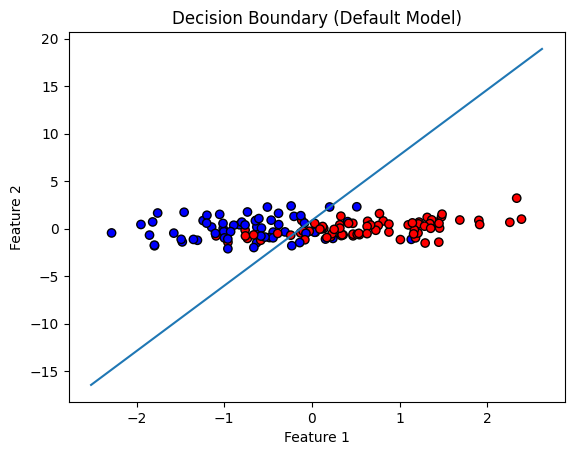


--- Training for different C values ---

C = 0.01
Weights: [[6.90363312e-03 7.66856183e-05]]
Bias: [-0.30352193]


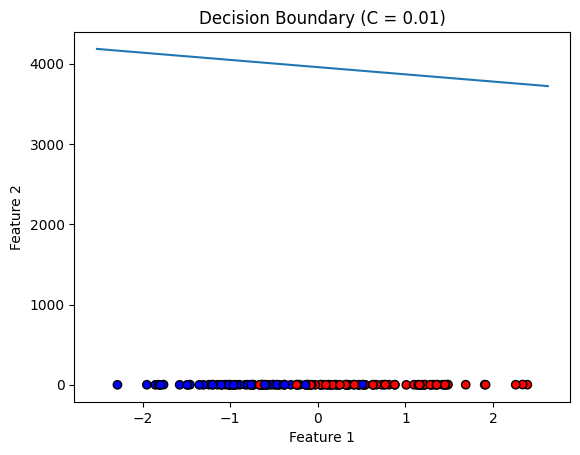


C = 0.1
Weights: [[0.06902602 0.00076674]]
Bias: [-0.44615081]


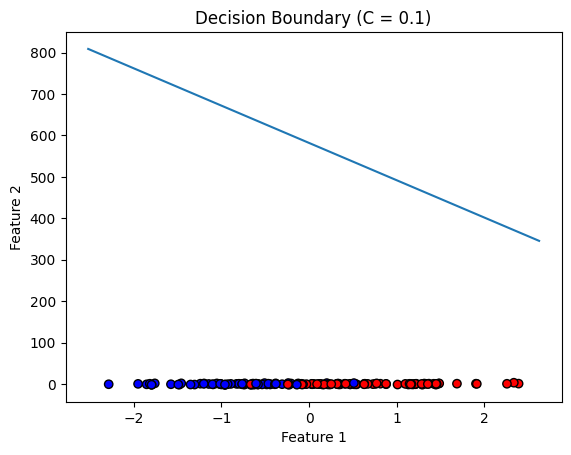


C = 1
Weights: [[ 0.55904238 -0.02664339]]
Bias: [0.04479168]


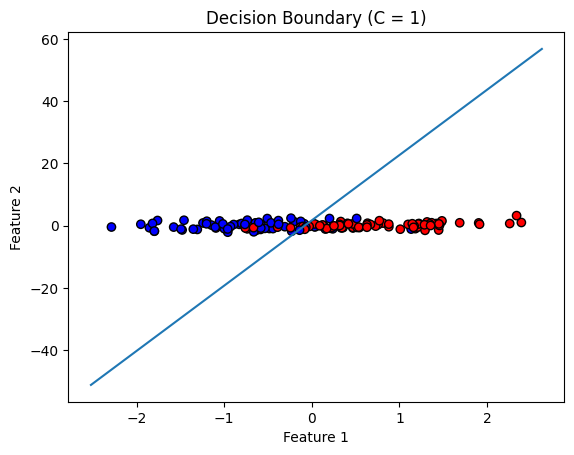


C = 10
Weights: [[ 1.22907268 -0.269205  ]]
Bias: [0.16686088]


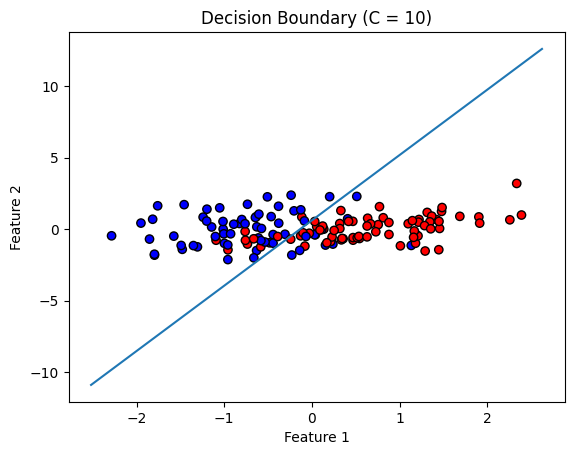


--- Model Evaluation ---
Accuracy: 0.8833333333333333
Precision: 0.8064516129032258
Recall: 0.9615384615384616


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

# -----------------------------
# 1. Generate Dataset
# -----------------------------
X, y = make_classification(n_samples=200, n_features=2, n_redundant=0,
                           n_informative=2, n_clusters_per_class=1,
                           random_state=42)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -----------------------------
# Function to plot decision boundary
# -----------------------------
def plot_decision_boundary(model, X, y, title):
    plt.figure()

    # Plot data points
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')

    # Decision boundary
    ax = plt.gca()
    x_vals = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 100)

    # w.x + b = 0 → x2 = -(w1*x1 + b)/w2
    w = model.coef_[0]
    b = model.intercept_[0]

    y_vals = -(w[0] * x_vals + b) / w[1]
    plt.plot(x_vals, y_vals)

    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()


# -----------------------------
# 2. Train SVM using SGD
# -----------------------------
print("\n--- Training SVM using SGD ---")

model = SGDClassifier(loss='hinge', alpha=0.01, max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Weight and bias
print("Weight vector (w):", model.coef_)
print("Bias (b):", model.intercept_)

# Plot boundary
plot_decision_boundary(model, X_train, y_train, "Decision Boundary (Default Model)")


# -----------------------------
# 3. Train for different C values
# -----------------------------
C_values = [0.01, 0.1, 1, 10]

print("\n--- Training for different C values ---")

for C in C_values:
    # alpha = 1/C (since SGD uses alpha instead of C)
    alpha = 1 / C

    model = SGDClassifier(loss='hinge', alpha=alpha, max_iter=1000, random_state=42)
    model.fit(X_train, y_train)

    print(f"\nC = {C}")
    print("Weights:", model.coef_)
    print("Bias:", model.intercept_)

    plot_decision_boundary(model, X_train, y_train, f"Decision Boundary (C = {C})")


# -----------------------------
# 4. Evaluation on Test Data
# -----------------------------
print("\n--- Model Evaluation ---")

model = SGDClassifier(loss='hinge', alpha=0.01, max_iter=1000, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)


